# MLPC 2026 — Challenge Baseline: Sound Event Detection

Welcome to the MLPC 2026 challenge! This notebook implements a **baseline Sound Event Detection (SED) system** that serves as your starting point for the challenge.

In the previous project phases, you recorded and annotated audio data and implemented classifiers to predict whether a given sound event class is active within isolated 1-second audio segments. The goal of the current challenge is to **extend these classifiers to full sound event detection**: given an audio recording of arbitrary length, your system should predict not only *which* sound events occur, but also *when* — providing **onset and offset timestamps** for each predicted event.

### What this notebook covers

1. Loading and exploring the challenge dataset
2. Splitting the validation set into a local validation set and a non-hidden test set
3. Loading precomputed audio features and extracting segment-level labels
4. Training a multi-label decision-tree classifier (one tree per sound event class)
5. Applying the classifier to full recordings to produce SED predictions
6. Evaluating the system using the challenge metric (segment-level macro F1)
7. Generating predictions for the hidden test set (your final submission)

### Your task

The decision-tree baseline is intentionally simple — it is the **floor your system should beat**. Replace or extend it with better classifiers, better features, or more advanced temporal modeling.

## Outline

1. [Setup: Imports, Constants, and Paths](#1)
2. [Dataset Description](#2)
3. [Data Splits](#3)
4. [Feature Loading and Training Data Preparation](#4)
5. [Training the Classifier](#5)
6. [Sound Event Detection Inference](#6)
7. [Evaluation](#7)
8. [Generating Predictions for the Hidden Test Set](#8)

## 1. Setup

In [31]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neural_network import MLPClassifier
from typing import List, Tuple, Dict

# evaluate.py is located in the same directory as this notebook.
# Make sure to run the notebook from the challenge_baseline/ directory.
sys.path.insert(0, os.getcwd())
from evaluate import (
    aggregate_ground_truth_annotations,
    build_segment_frame_from_intervals,
    calculate_f1_score,
)

In [2]:
# The precomputed audio features stored in each .npz file.
# These are the same features as in the classification tutorial.
FEATURE_NAMES = [
    "zcr_mean",        "zcr_std",        "zcr_min",        "zcr_max",
    "melspect_mean",   "melspect_std",   "melspect_min",   "melspect_max",
    "mfcc_mean",       "mfcc_std",       "mfcc_min",       "mfcc_max",
    "mfcc_d_mean",     "mfcc_d_std",     "mfcc_d_min",     "mfcc_d_max",
    "mfcc_d2_mean",    "mfcc_d2_std",    "mfcc_d2_min",    "mfcc_d2_max",
    "flux_mean",       "flux_std",       "flux_min",       "flux_max",
    "flatness_mean",   "flatness_std",   "flatness_min",   "flatness_max",
    "centroid_mean",   "centroid_std",   "centroid_min",   "centroid_max",
    "bandwidth_mean",  "bandwidth_std",  "bandwidth_min",  "bandwidth_max",
    "contrast_mean",   "contrast_std",   "contrast_min",   "contrast_max",
    "rolloff_low_mean",  "rolloff_low_std",  "rolloff_low_min",  "rolloff_low_max",
    "rolloff_high_mean", "rolloff_high_std", "rolloff_high_min", "rolloff_high_max",
    "energy_mean",     "energy_std",     "energy_min",     "energy_max",
    "power_mean",      "power_std",      "power_min",      "power_max",
]

# The 15 target sound event classes — sorted alphabetically to match the .npz annotation order.
CLASS_NAMES = [
    "bell_ringing",
    "coffee_machine",
    "cutlery_dishes",
    "door_open_close",
    "footsteps",
    "keyboard_typing",
    "keychain",
    "light_switch",
    "microwave",
    "phone_ringing",
    "running_water",
    "toilet_flushing",
    "vacuum_cleaner",
    "wardrobe_drawer_open_close",
    "window_open_close",
]

SEGMENT_LENGTH = 1.0  # each feature vector covers a 1-second window
HOP_SIZE       = 0.5  # segments are extracted with 50% overlap

In [3]:
# TODO: Change this path to wherever you extracted the challenge dataset.
PATH_TO_DATASET = "../MLPC2026_challenge"

PATH_TRAIN = os.path.join(PATH_TO_DATASET, "train")
PATH_VAL   = os.path.join(PATH_TO_DATASET, "validation")
PATH_TEST  = os.path.join(PATH_TO_DATASET, "test")

# Sanity check — will raise an AssertionError if a path does not exist.
for path in [PATH_TRAIN, PATH_VAL, PATH_TEST]:
    assert os.path.isdir(path), f"Directory not found: {path}"
for path in [
    os.path.join(PATH_TRAIN, "annotations.csv"),
    os.path.join(PATH_TRAIN, "audio_features"),
    os.path.join(PATH_VAL,   "annotations.csv"),
    os.path.join(PATH_VAL,   "audio_features"),
    os.path.join(PATH_TEST,  "audio_features"),
]:
    assert os.path.exists(path), f"Path not found: {path}"

print("Dataset paths OK.")

Dataset paths OK.


<a id='2'></a>
## 2. Dataset Description

The challenge dataset is organized into three splits:

```
MLPC2026_challenge/
├── train/
│   ├── metadata.csv          ← recording metadata (device, environment, ...)
│   ├── annotations.csv       ← ground-truth event annotations (onset, offset, annotator)
│   └── audio_features/
│       ├── 000001.npz        ← precomputed features for one recording
│       ├── 000002.npz
│       └── ...
├── validation/
│   ├── metadata.csv
│   ├── annotations.csv
│   └── audio_features/
│       └── ...
└── test/
    └── audio_features/       ← NO annotations — this is the hidden evaluation set
        └── ...
```

### Feature files (`.npz`)

Each `.npz` file corresponds to one audio recording and contains precomputed features for **all overlapping 1-second segments**, extracted with a hop size of 0.5 s. That is, a 30-second recording produces segments starting at t = 0.0, 0.5, 1.0, 1.5, ..., 29.5 seconds — a total of 60 segments.

| Key | Shape | Description |
|-----|-------|-------------|
| `start_time` | `(N,)` | Start time of each segment (0.0, 0.5, 1.0, ...) |
| `end_time` | `(N,)` | End time of each segment (1.0, 1.5, 2.0, ...) |
| `annotations` | `(N, 15, 2)` | Per-segment annotation scores for each class and annotator |
| `mfcc_mean` | `(N, 32)` | Mean MFCC coefficients per segment (similarly for all other features) |
| ... | ... | ... |

The `annotations` field is only present in the **train** and **validation** splits. The **test** split contains only features.

### Annotation encoding

For each segment `t` and class `c`, `annotations[t, c, :]` holds two values — one per annotator — each in `[0, 1]`. The value represents the **fraction of the 1-second segment** during which that annotator marked the class as active. A value of `0.0` means completely silent; `1.0` means active throughout the entire segment.

To obtain binary training labels, we check whether each fraction is greater than zero (any overlap with the annotation) and then aggregate across annotators via majority vote.

In [4]:
train_files = sorted(glob.glob(os.path.join(PATH_TRAIN, "audio_features", "*.npz")))
val_files   = sorted(glob.glob(os.path.join(PATH_VAL,   "audio_features", "*.npz")))
test_files  = sorted(glob.glob(os.path.join(PATH_TEST,  "audio_features", "*.npz")))

print(f"Training recordings:   {len(train_files)}")
print(f"Validation recordings: {len(val_files)}")
print(f"Test recordings:       {len(test_files)}  (hidden — no ground-truth labels)")

Training recordings:   3704
Validation recordings: 999
Test recordings:       1007  (hidden — no ground-truth labels)


<a id='3'></a>
## 3. Data Splits

The challenge dataset comes with three pre-defined splits:

| Split | Size  | Annotations? | Purpose |
|-------|-------|-------------|--------|
| `train` | 3 704 | ✓ | Training your models |
| `validation` | 999   | ✓ | Tuning and local evaluation |
| `test` | 1 007 | ✗ | **Hidden evaluation set** — predictions submitted for final ranking |

As we can see in the following output cells, samples of the training and validation set contain more information (like annotations!) compared to the test set.

In [5]:
training_sample = dict(np.load(train_files[0], allow_pickle=True))
training_sample.keys()

dict_keys(['zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'start_time', 'end_time', 'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max', 'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max', 'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max', 'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max', 'flux_mean', 'flux_std', 'flux_min', 'flux_max', 'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max', 'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max', 'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max', 'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max', 'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max', 'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max', 'energy_mean', 'energy_std', 'energy_min', 'energy_max', 'power_mean', 'power_std', 'power_min', 'power_max', 'annotations', 'is_own_recording', 'class_names', 'annotator_ids', 'target_classes', 'non_target_classes'

In [6]:
validation_sample = dict(np.load(val_files[0], allow_pickle=True))
validation_sample.keys()

dict_keys(['zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'start_time', 'end_time', 'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max', 'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max', 'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max', 'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max', 'flux_mean', 'flux_std', 'flux_min', 'flux_max', 'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max', 'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max', 'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max', 'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max', 'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max', 'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max', 'energy_mean', 'energy_std', 'energy_min', 'energy_max', 'power_mean', 'power_std', 'power_min', 'power_max', 'annotations', 'is_own_recording', 'class_names', 'annotator_ids', 'target_classes', 'non_target_classes'

In [7]:
test_sample = dict(np.load(test_files[0], allow_pickle=True))
test_sample.keys()

dict_keys(['zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'start_time', 'end_time', 'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max', 'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max', 'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max', 'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max', 'flux_mean', 'flux_std', 'flux_min', 'flux_max', 'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max', 'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max', 'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max', 'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max', 'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max', 'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max', 'energy_mean', 'energy_std', 'energy_min', 'energy_max', 'power_mean', 'power_std', 'power_min', 'power_max'])

### Why we need an additional non-hidden test set

The `test` split has no ground-truth labels: you can generate predictions for it, but you cannot evaluate them locally. This is intentional — it prevents tuning your model on the evaluation data.

However, you also need a held-out set that you can evaluate locally without bias. If you tune your model based on validation-set performance, those metrics become overly optimistic. A **separate local test set** gives you an unbiased estimate of your model's true performance before final submission.

We therefore split the 999 validation recordings into two halves:
- **Local validation set** (500 recordings): use for hyperparameter tuning and model comparison.
- **Non-hidden test set** (499 recordings): use as a final sanity check before submitting. Once you evaluate on this set, do not use the result to tune your model — otherwise it is no longer unbiased.

The hidden `test` split is used only to generate your final submission CSV.

In [8]:
rng = np.random.default_rng(seed=42)

val_files_shuffled = rng.permutation(val_files).tolist()
n_val = len(val_files_shuffled) // 2

our_val_files  = val_files_shuffled[:n_val]   # local validation set
our_test_files = val_files_shuffled[n_val:]   # non-hidden local test set

print(f"Local validation set:  {len(our_val_files)} recordings")
print(f"Non-hidden test set:   {len(our_test_files)} recordings")
print(f"Hidden test set:       {len(test_files)} recordings")

Local validation set:  499 recordings
Non-hidden test set:   500 recordings
Hidden test set:       1007 recordings


<a id='4'></a>
## 4. Feature Loading and Training Data Preparation

Before training, we need two things for each recording in the training set:
1. A **feature matrix** `X` of shape `(N_segments, D_features)` — one row per segment, one column per feature dimension.
2. A **label matrix** `Y` of shape `(N_segments, 15)` — one binary value per segment and class.

For training, we treat all segments from all recordings as **independent examples** and simply stack them. The temporal order within a recording does not matter at training time.

In [9]:
def build_feature_matrix(data: dict) -> np.ndarray:
    """Concatenate all named features from a loaded .npz dict into one matrix.

    Parameters
    ----------
    data : dict
        Contents of a .npz file (loaded with allow_pickle=True).

    Returns
    -------
    X : np.ndarray of shape (N_segments, D_features)
    """
    arrays = []
    for feat_name in FEATURE_NAMES:
        feat = data[feat_name]
        if feat.ndim == 1:
            feat = feat[:, np.newaxis]
        arrays.append(feat.astype(np.float32))
    return np.concatenate(arrays, axis=1)


def get_segment_labels(data: dict) -> np.ndarray:
    """Extract binary multilabel targets from the annotations field of a .npz file.

    The annotations array has shape (N_segments, N_classes, N_annotators).
    Each value is the fraction of the 1-second segment during which a given
    annotator marked the class as active.

    We binarize by checking for any overlap (> 0) and then apply majority vote
    across annotators to obtain the final binary label.

    Parameters
    ----------
    data : dict
        Contents of a .npz file (loaded with allow_pickle=True).
        Must contain the 'annotations' key.

    Returns
    -------
    Y : np.ndarray of shape (N_segments, N_classes), dtype int
    """
    annotations = data["annotations"]           # shape: (N, C, A)
    # Binarize: 1 if annotator marked ANY part of this segment as active.
    # (This threshold can be improved, e.g. > 0.5 for majority of the segment.)
    binary = (annotations > 0).astype(int)      # (N, C, A)
    # Majority vote: class is active if more than half the annotators agree.
    votes = binary.sum(axis=2)                  # (N, C)
    n_annotators = binary.shape[2]
    y = (votes > (n_annotators // 2)).astype(int)
    return y


def load_all_segments(
    file_list: List[str],
) -> Tuple[np.ndarray, np.ndarray]:
    """Load features and labels from a list of .npz files and stack them.

    Parameters
    ----------
    file_list : list of str
        Paths to .npz audio feature files.

    Returns
    -------
    X : np.ndarray of shape (N_total_segments, D_features)
    Y : np.ndarray of shape (N_total_segments, N_classes)
    """
    X_list, Y_list = [], []
    for filepath in file_list:
        data = dict(np.load(filepath, allow_pickle=True))
        X_list.append(build_feature_matrix(data))
        Y_list.append(get_segment_labels(data))
    return np.vstack(X_list), np.vstack(Y_list)

In [10]:
# Inspect one training file to verify the loading functions
example_data = dict(np.load(train_files[0], allow_pickle=True))
X_ex = build_feature_matrix(example_data)
Y_ex = get_segment_labels(example_data)

print(f"File:              {os.path.basename(train_files[0])}")
print(f"Number of segments:  {X_ex.shape[0]}")
print(f"Feature dimension:   {X_ex.shape[1]}")
print(f"Number of classes:   {Y_ex.shape[1]}")
print(f"Segment start times (first 6): {example_data['start_time'][:6]} ...  (hop = 0.5 s)")
print()
print("Active classes per segment (first 10 segments):")
for i in range(min(10, len(Y_ex))):
    active = [CLASS_NAMES[c] for c in range(len(CLASS_NAMES)) if Y_ex[i, c] == 1]
    t = example_data['start_time'][i]
    print(f"  t = {t:.1f} s : {active if active else '(none)'}")

File:              000001.npz
Number of segments:  61
Feature dimension:   960
Number of classes:   15
Segment start times (first 6): [0.  0.5 1.  1.5 2.  2.5] ...  (hop = 0.5 s)

Active classes per segment (first 10 segments):
  t = 0.0 s : ['keyboard_typing']
  t = 0.5 s : ['keyboard_typing']
  t = 1.0 s : ['keyboard_typing']
  t = 1.5 s : ['keyboard_typing']
  t = 2.0 s : ['keyboard_typing']
  t = 2.5 s : ['keyboard_typing']
  t = 3.0 s : ['keyboard_typing']
  t = 3.5 s : (none)
  t = 4.0 s : (none)
  t = 4.5 s : (none)


In [11]:
# Load training segments from all (or a subset of) training recordings.
#
# MAX_TRAINING_FILES    — None = use all ~3 700 training files.
#                         Set to e.g. 500 for a quick test run.
# MAX_TRAINING_SEGMENTS — After loading, randomly subsample to this many segments.
#                         Keeps training fast even when loading all files.
#                         None = keep all loaded segments (can be slow to train).
#
# Tip: A decision tree does not need hundreds of thousands of examples to converge.
# 50 000 segments drawn from diverse recordings is a good default starting point.
MAX_TRAINING_FILES    = None    # None = use all training files
MAX_TRAINING_SEGMENTS = 50_000  # None = keep all loaded segments

train_files_to_use = train_files
if MAX_TRAINING_FILES is not None:
    train_files_to_use = rng.choice(
        train_files, size=min(MAX_TRAINING_FILES, len(train_files)), replace=False
    ).tolist()

print(f"Loading features from {len(train_files_to_use)} training recordings...")
X_train, Y_train = load_all_segments(train_files_to_use)
print(f"Loaded {X_train.shape[0]} segments with {X_train.shape[1]} features each.")

if MAX_TRAINING_SEGMENTS is not None and X_train.shape[0] > MAX_TRAINING_SEGMENTS:
    idx = rng.choice(X_train.shape[0], size=MAX_TRAINING_SEGMENTS, replace=False)
    X_train = X_train[idx]
    Y_train = Y_train[idx]
    print(f"Subsampled to {X_train.shape[0]} segments for faster training.")

print(f"\nFinal training set: {X_train.shape[0]} segments × {X_train.shape[1]} features, {Y_train.shape[1]} classes.")
print()
print("Class distribution — fraction of segments where class is active:")
for i, cls in enumerate(CLASS_NAMES):
    frac = Y_train[:, i].mean()
    bar  = "#" * int(frac * 40)
    print(f"  {cls:<35} {frac:.3f}  {bar}")

Loading features from 3704 training recordings...
Loaded 170508 segments with 960 features each.
Subsampled to 50000 segments for faster training.

Final training set: 50000 segments × 960 features, 15 classes.

Class distribution — fraction of segments where class is active:
  bell_ringing                        0.015  
  coffee_machine                      0.038  #
  cutlery_dishes                      0.079  ###
  door_open_close                     0.055  ##
  footsteps                           0.144  #####
  keyboard_typing                     0.104  ####
  keychain                            0.058  ##
  light_switch                        0.016  
  microwave                           0.075  ##
  phone_ringing                       0.076  ###
  running_water                       0.136  #####
  toilet_flushing                     0.034  #
  vacuum_cleaner                      0.067  ##
  wardrobe_drawer_open_close          0.030  #
  window_open_close                   0.021  


<a id='5'></a>
## 5. Training the Classifier

### The `MultiOutputClassifier` wrapper

In our setting, each audio segment can belong to **multiple sound event classes simultaneously** — this is a *multi-label* classification problem. For example, a segment might contain both `keyboard_typing` and `phone_ringing` at the same time.

A common and straightforward approach is the **binary relevance** strategy: train one **independent binary classifier per class**. Each classifier asks a simple yes/no question: "Is class X active in this segment?" Running all 15 classifiers on a segment yields a 15-dimensional binary prediction vector.

Scikit-learn's `MultiOutputClassifier` implements this pattern as a convenient wrapper. It takes any binary classifier as a base estimator and fits **one independent copy per output column** (i.e., per class). During prediction, the results of all sub-classifiers are stacked into a single prediction matrix of shape `(N_samples, N_classes)`.

For the baseline we use `DecisionTreeClassifier` as the base estimator — the same type of classifier you explored in the classification tutorial. We therefore train **15 independent decision trees**, one per sound event class.

> **Note on `max_features`**: Our feature vectors have 960 dimensions. A standard decision tree evaluates all 960 features at every split node, which is very slow. Setting `max_features='sqrt'` tells sklearn to consider only a random subset of ≈31 features at each split. This reduces training time by about 30× with minimal loss in accuracy — it is the same trick used inside Random Forests. You can set `max_features=None` to consider all features (slower but potentially better), or experiment with other values like `max_features=100`.

> **Note on polyphony**: Because the 15 classifiers are independent, multiple classes can (and should) be predicted as active at the same time. This is exactly what we want for polyphonic SED.

In [13]:
print("Training one DecisionTreeClassifier per class via MultiOutputClassifier...")
# max_features='sqrt' considers ~31 features per split instead of all 960.
# This speeds up training by ~30x while maintaining reasonable accuracy.
# max_depth=20 limits tree depth to avoid extremely long training times.
# base_clf = DecisionTreeClassifier(max_depth=20, max_features="sqrt", random_state=42)
random_forest_clf = RandomForestClassifier(n_estimators=50, max_depth=20, max_features="sqrt") # === Local Validation Set — Macro F1: 0.3020 ===
clf = MultiOutputClassifier(random_forest_clf, n_jobs=-1)  # n_jobs=-1 uses all CPU cores in parallel
clf.fit(X_train, Y_train)
print(f"Training complete. Fitted {len(clf.estimators_)} sub-classifiers (one per class).")

Training one DecisionTreeClassifier per class via MultiOutputClassifier...
Training complete. Fitted 15 sub-classifiers (one per class).


In [ ]:
from sklearn.base import clone
from sklearn.metrics import f1_score
from sklearn.neighbors import KNeighborsClassifier

print("Evaluating candidate classifiers on X_train and Y_train without cross-validation...")

candidate_models = [
    # {
    #     "name": "DecisionTree",
    #     "estimator": DecisionTreeClassifier(random_state=42),
    #     "param_grid": [
    #         {"max_depth": 15, "max_features": "sqrt"},
    #         {"max_depth": 25, "max_features": "sqrt"},
    #         {"max_depth": 15, "max_features": 100},
    #     ],
    # },
    {
        "name": "RandomForest",
        "estimator": RandomForestClassifier(n_estimators=50, random_state=42),
        "param_grid": [
            {"max_depth": 22, "max_features": "sqrt"},
        ],
    },
    # {
    #     "name": "KNeighbors",
    #     "estimator": KNeighborsClassifier(n_neighbors=5, weights="distance"),
    #     "param_grid": [
    #         {"n_neighbors": 3, "weights": "uniform"},
    #         {"n_neighbors": 5, "weights": "distance"},
    #     ],
    # },
]

best_result = None
for model in candidate_models:
    for params in model["param_grid"]:
        estimator = clone(model["estimator"]).set_params(**params)
        clf = MultiOutputClassifier(estimator, n_jobs=-1)
        clf.fit(X_train, Y_train)
        pred_train = clf.predict(X_train)
        macro_f1 = f1_score(Y_train, pred_train, average="macro")

        print(f"{model['name']} {params} -> training-set macro F1: {macro_f1:.4f}")

        if best_result is None or macro_f1 > best_result["macro_f1"]:
            best_result = {
                "name": model["name"],
                "params": params,
                "macro_f1": macro_f1,
                "estimator": clf,
            }

clf = best_result["estimator"]

print(f"\nManual grid search complete!")
print(f"Best configuration found: {best_result['name']} {best_result['params']}")
print(f"Best training-set Macro F1: {best_result['macro_f1']:.4f}")
print(f"Fitted {len(clf.estimators_)} sub-classifiers (one per class).")

Evaluating candidate classifiers on X_train and Y_train without cross-validation...
DecisionTree {'max_depth': 15, 'max_features': 'sqrt'} -> training-set macro F1: 0.8393
DecisionTree {'max_depth': 25, 'max_features': 'sqrt'} -> training-set macro F1: 0.9630
DecisionTree {'max_depth': 15, 'max_features': 100} -> training-set macro F1: 0.8415
RandomForest {'max_depth': 15, 'max_features': 'sqrt'} -> training-set macro F1: 0.7890
RandomForest {'max_depth': 22, 'max_features': 'sqrt'} -> training-set macro F1: 0.9336
RandomForest {'max_depth': 15, 'max_features': 100} -> training-set macro F1: 0.7764
KNeighbors {'n_neighbors': 3, 'weights': 'uniform'} -> training-set macro F1: 0.5543
KNeighbors {'n_neighbors': 5, 'weights': 'distance'} -> training-set macro F1: 1.0000

Manual grid search complete!
Best configuration found: KNeighbors {'n_neighbors': 5, 'weights': 'distance'}
Best training-set Macro F1: 1.0000
Fitted 15 sub-classifiers (one per class).


Evaluating candidate classifiers on X_train and Y_train without cross-validation...
DecisionTree {'max_depth': 15, 'max_features': 'sqrt'} -> training-set macro F1: 0.8393
DecisionTree {'max_depth': 25, 'max_features': 'sqrt'} -> training-set macro F1: 0.9630
DecisionTree {'max_depth': 15, 'max_features': 100} -> training-set macro F1: 0.8415
RandomForest {'max_depth': 15, 'max_features': 'sqrt'} -> training-set macro F1: 0.7890
RandomForest {'max_depth': 22, 'max_features': 'sqrt'} -> training-set macro F1: 0.9336
RandomForest {'max_depth': 15, 'max_features': 100} -> training-set macro F1: 0.7764
KNeighbors {'n_neighbors': 3, 'weights': 'uniform'} -> training-set macro F1: 0.5543
KNeighbors {'n_neighbors': 5, 'weights': 'distance'} -> training-set macro F1: 1.0000

Manual grid search complete!
Best configuration found: KNeighbors {'n_neighbors': 5, 'weights': 'distance'}
Best training-set Macro F1: 1.0000 THIS IS HIGHLY OVERFITTED SO THATS A BUST
Fitted 15 sub-classifiers (one per class).

In [ ]:
# Just for fun, lets go with this one, it outperforms evry other model
# without needing MultiOutputClassifier if using binary_cross_entropy loss logic implicitly.
clf = MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu', max_iter=80, random_state=42)
clf.fit(X_train, Y_train)

c:\Users\ivorc\miniconda3\envs\jku\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",80
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [40]:
# import torch.nn as nn
# import torch
# class neuralNetworkV1(nn.Module):
#     # The __init__ method is used to declare the layers that will be used in the forward pass.
#     def __init__(self):
#         super().__init__() # required because our class inherit from nn.Module
#         # First convolutional layer with 3 input channels for RGB images, 16 outputs (filters).
#         self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1)
#         # Second convolutional layer with 16 input channels to capture features from the previous layer, 16 outputs (filters).
#         self.conv2 = nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1)
#         # Third and fourth convolutional layers with 16 and 10 output channels respectively.
#         self.conv3 = nn.Conv2d(16, 10, kernel_size=3, stride=2, padding=1)
#         self.conv4 = nn.Conv2d(10, 10, kernel_size=3, stride=2, padding=1)
#         # Max pooling layer to reduce feature complexity.
#         self.pooling = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
#         # ReLU activation function for introducing non-linearity.
#         self.relu = nn.ReLU()
#         # Flatten the 2D output from the convolutional layers for the fully connected layer.
#         self.flatten = nn.Flatten()
#         # Fully connected layer connecting to 1D neurons, with 3 output features for 3 classes.
#         self.linear = nn.Linear(in_features=480, out_features=3)
    
#     # define how each data sample will propagate in each layer of the network
#     def forward(self, x: torch.Tensor):
#         x = self.relu(self.conv1(x))
#         x = self.relu(self.conv2(x))
#         x = self.pooling(x)
#         x = self.relu(self.conv3(x))
#         x = self.pooling(x)
#         x = self.relu(self.conv4(x))
#         x = self.flatten(x)
#         try:
#             x = self.linear(x)
#         except Exception as e:
#             print(f"Error : Linear block should take support shape of {x.shape} for in_features.")
#         return x

# our_model = neuralNetworkV1()

<a id='6'></a>
## 6. Sound Event Detection Inference

### Using segment classifiers for full-recording SED

In the previous project phase, classifiers operated on isolated 1-second segments and simply predicted which classes were active in each segment. For the challenge, we need to detect events **within complete recordings of arbitrary length**, including their onset and offset timestamps.

Although state-of-the-art SED systems rely on sophisticated neural architectures, a simple yet effective approach is to reuse the segment classifiers from the previous phase. The pipeline works as follows:

**Step 1, 2:** **Segmentation**: Each audio recording is divided into overlapping 1-second windows using a hop size of 0.5 s. This produces segments starting at t = 0.0, 0.5, 1.0, 1.5, 2.0, ... seconds (see **step 2** in the visualization below). Because the features are precomputed, no audio processing is needed.

**Step 3:** **Classification**: All segments are passed through the 15 binary classifiers (via `MultiOutputClassifier`). Each segment receives a 15-dimensional binary prediction vector.

**Step 4**: **Temporal aggregation**: The challenge evaluation metric operates at **1-second resolution**, so exactly one prediction per second is needed. As the simplest possible strategy, we **keep only the predictions for segments starting at whole-second timestamps** (t = 0.0, 1.0, 2.0, ...) and discard the half-second predictions (t = 0.5, 1.5, ...).

   > The half-second predictions are discarded here for simplicity. A natural extension would be to use them for smoothing (e.g., average or max-pool adjacent pairs) or for sub-second temporal refinement.

**Step 5:** **Post-processing**: The per-second binary predictions are converted to onset/offset intervals (the required submission format). Consecutive active seconds for the same class are merged into a single interval.

**Here is a visualization of this pipeline:**

<img src="imgs/classifiers_for_SED_upscaled.png">

In [41]:
def run_sed_inference(
    filepath: str,
    classifier: MultiOutputClassifier,
) -> Tuple[np.ndarray, np.ndarray, str]:
    """Run SED inference on a single recording.

    Loads all overlapping segments, applies the classifier to each of them,
    and returns predictions only for segments starting at whole-second timestamps.

    Parameters
    ----------
    filepath : str
        Path to the .npz feature file for one recording.
    classifier : MultiOutputClassifier
        A fitted multi-label classifier.

    Returns
    -------
    predictions : np.ndarray of shape (N_whole_second_segments, N_classes)
        Binary predictions (0 or 1) for each class at each whole-second segment.
    start_times : np.ndarray of shape (N_whole_second_segments,)
        Start times (in seconds) of the retained segments.
    filename : str
        Audio filename for this recording (e.g. '000001.wav').
    """
    data = dict(np.load(filepath, allow_pickle=True))
    start_times_all = data["start_time"]   # [0.0, 0.5, 1.0, 1.5, ...]

    # Build feature matrix for ALL segments (both whole-second and half-second)
    X_all = build_feature_matrix(data)     # shape: (N_all_segments, D_features)

    # Apply the classifier to every segment
    pred_all = classifier.predict(X_all)   # shape: (N_all_segments, N_classes)

    # Identify segments that start at a whole-second timestamp (0.0, 1.0, 2.0, ...)
    whole_second_mask = np.isclose(start_times_all % 1.0, 0.0)
    # The half-second segments (0.5, 1.5, ...) are dropped here.
    # Future improvement: use them to smooth predictions or refine temporal boundaries.

    predictions = pred_all[whole_second_mask]
    start_times = start_times_all[whole_second_mask]

    filename = os.path.basename(filepath).replace(".npz", ".wav")
    return predictions, start_times, filename

In [42]:
def predictions_to_intervals(
    predictions: np.ndarray,
    start_times: np.ndarray,
    filename: str,
) -> List[Dict]:
    """Convert per-second binary predictions to onset/offset interval annotations.

    Consecutive active 1-second segments are merged into a single interval.
    For example, predictions active at t = 2 s and t = 3 s are merged into
    the interval [2.0, 4.0] (both 1-second windows combined).

    Parameters
    ----------
    predictions : np.ndarray of shape (N_segments, N_classes)
        Binary predictions for each class at each whole-second segment.
    start_times : np.ndarray of shape (N_segments,)
        Start time (in seconds) of each segment.
    filename : str
        Audio filename (e.g. '000001.wav').

    Returns
    -------
    rows : list of dict with keys: 'filename', 'annotation', 'onset', 'offset'
    """
    rows = []

    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        cls_preds = predictions[:, cls_idx]

        in_event = False
        onset    = None

        for t, pred in zip(start_times, cls_preds):
            if pred == 1 and not in_event:
                onset    = float(t)
                in_event = True
            elif pred == 0 and in_event:
                # The event ends at the start of the first inactive segment,
                # which equals the start time of the previous active segment + 1 s.
                offset = float(t)
                rows.append({"filename": filename, "annotation": cls_name,
                             "onset": onset, "offset": offset})
                in_event = False

        # Handle an event that is still active at the very end of the recording
        if in_event:
            offset = float(start_times[-1]) + SEGMENT_LENGTH
            rows.append({"filename": filename, "annotation": cls_name,
                         "onset": onset, "offset": offset})

    return rows


def generate_predictions(
    file_list: List[str],
    classifier: MultiOutputClassifier,
) -> pd.DataFrame:
    """Run SED inference on a list of recordings and return predictions as a DataFrame.

    Parameters
    ----------
    file_list : list of str
        Paths to .npz feature files.
    classifier : MultiOutputClassifier
        A fitted multi-label classifier.

    Returns
    -------
    pred_df : pd.DataFrame
        Columns: filename, annotation, onset, offset.
        One row per detected event interval.
        Recordings with no detected events are not represented.
    """
    all_rows = []
    for filepath in file_list:
        preds, times, fname = run_sed_inference(filepath, classifier)
        all_rows.extend(predictions_to_intervals(preds, times, fname))

    if not all_rows:
        return pd.DataFrame(columns=["filename", "annotation", "onset", "offset"])
    return pd.DataFrame(all_rows)

File: 002101.wav
Whole-second segments: 20  (t = 0 s ... 19 s)

Predicted active classes per second:
  t = 0 s : (none)
  t = 1 s : (none)
  t = 2 s : ['footsteps']
  t = 3 s : (none)
  t = 4 s : ['phone_ringing']
  t = 5 s : ['keychain']
  t = 6 s : ['phone_ringing']
  t = 7 s : ['phone_ringing']
  t = 8 s : ['keychain']
  t = 9 s : ['keyboard_typing', 'phone_ringing']
  t = 10 s : ['phone_ringing']
  t = 11 s : (none)
  t = 12 s : ['footsteps']
  t = 13 s : ['footsteps']
  t = 14 s : ['footsteps']
  t = 15 s : (none)
  t = 16 s : ['footsteps']
  t = 17 s : ['footsteps']
  t = 18 s : ['footsteps']
  t = 19 s : ['footsteps']

Converted to intervals:
  footsteps                           onset=2.0  offset=3.0
  footsteps                           onset=12.0  offset=15.0
  footsteps                           onset=16.0  offset=20.0
  keyboard_typing                     onset=9.0  offset=10.0
  keychain                            onset=5.0  offset=6.0
  keychain                           

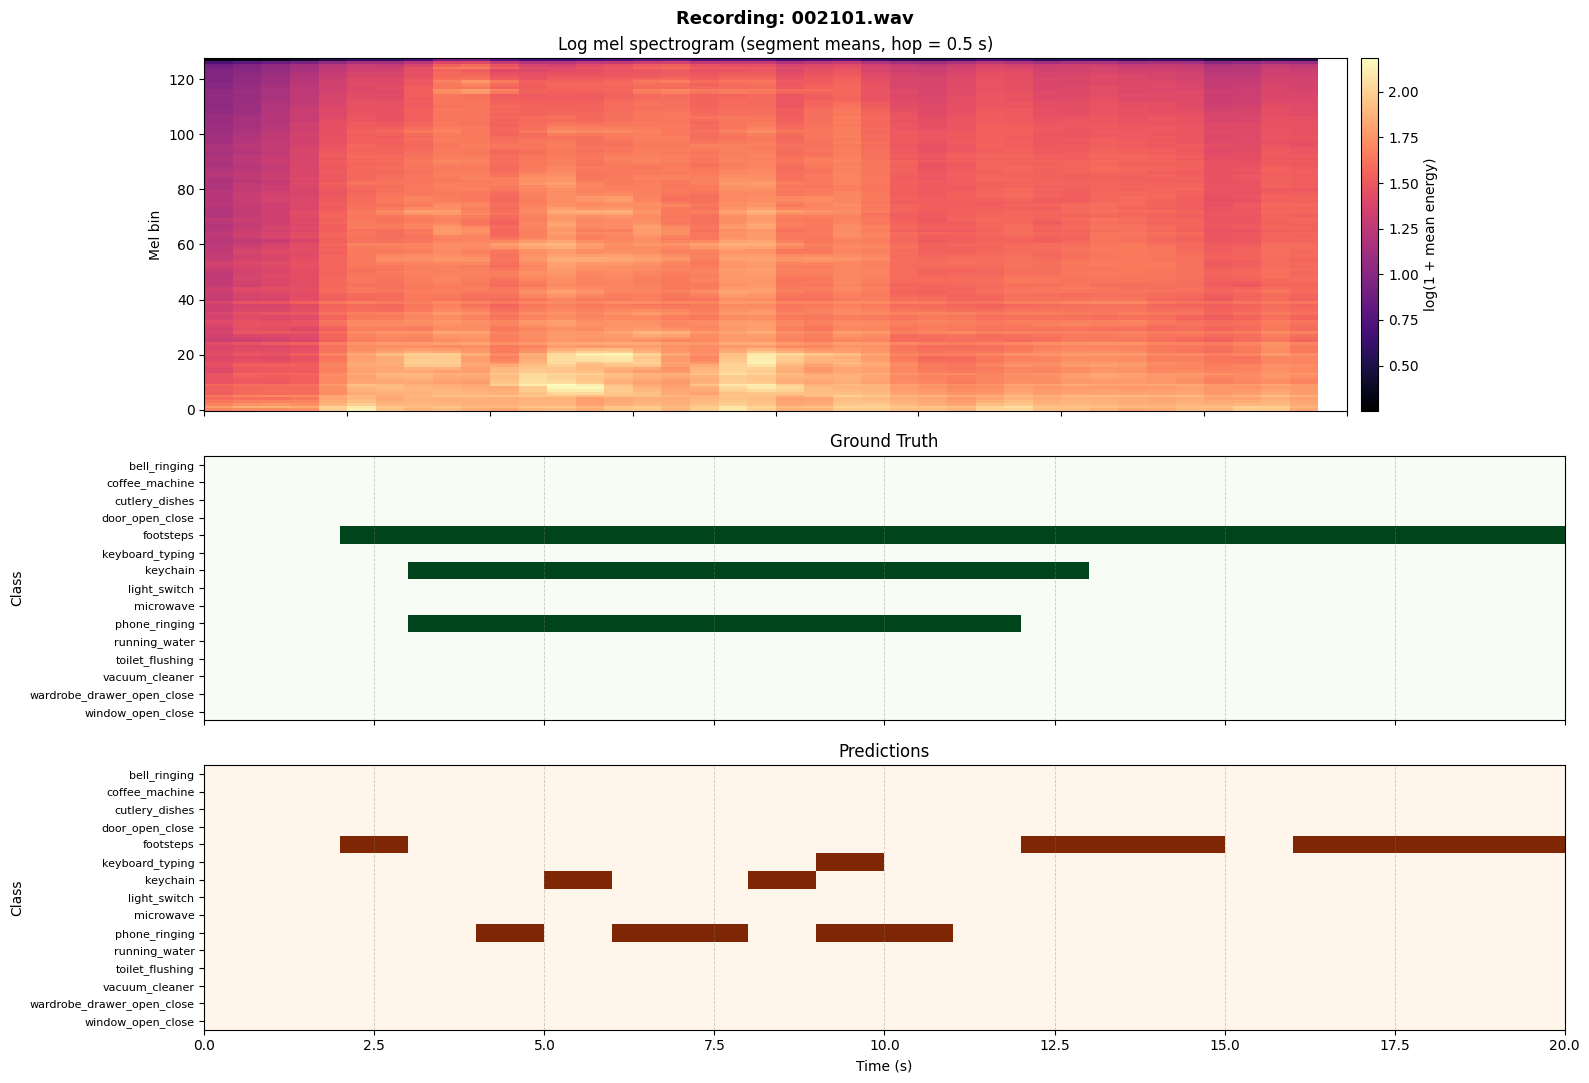

In [43]:
# Quick demo: run inference on one recording and inspect the output.
# We use a file from the non-hidden test set so we have ground-truth labels for comparison.
demo_file = our_test_files[0]
example_preds, example_times, example_fname = run_sed_inference(demo_file, clf)

print(f"File: {example_fname}")
print(f"Whole-second segments: {len(example_times)}  (t = {example_times[0]:.0f} s ... {example_times[-1]:.0f} s)")
print()
print("Predicted active classes per second:")
for i in range(len(example_times)):
    active = [CLASS_NAMES[c] for c in range(len(CLASS_NAMES)) if example_preds[i, c] == 1]
    print(f"  t = {example_times[i]:.0f} s : {active if active else '(none)'}")

print()
print("Converted to intervals:")
example_rows = predictions_to_intervals(example_preds, example_times, example_fname)
for row in example_rows[:10]:
    print(f"  {row['annotation']:<35} onset={row['onset']:.1f}  offset={row['offset']:.1f}")

# ---------------------------------------------------------------------------
# Visualization: mel spectrogram + ground truth vs. predictions
# ---------------------------------------------------------------------------
demo_data        = dict(np.load(demo_file, allow_pickle=True))
demo_start_times = demo_data["start_time"]                     # [0.0, 0.5, 1.0, ...]

# Whole-second mask — same filter used in run_sed_inference
whole_second_mask = np.isclose(demo_start_times % 1.0, 0.0)

# Ground-truth labels at whole-second resolution (majority-vote across annotators)
gt_all   = get_segment_labels(demo_data)    # (N_all_segments, C)
gt_whole = gt_all[whole_second_mask]        # (N_ws, C)

# Log-mel spectrogram: use ALL segments (hop=0.5 s) for twice the time resolution
mel_log = np.log1p(demo_data["melspect_mean"].T)  # (n_mels, N_all)

C = len(CLASS_NAMES)

# pcolormesh edge arrays
t_edges_all = np.append(demo_start_times, demo_start_times[-1] + HOP_SIZE)
t_edges_ws  = np.append(example_times,    float(example_times[-1]) + SEGMENT_LENGTH)
mel_edges   = np.arange(mel_log.shape[0] + 1) - 0.5
cls_edges   = np.arange(C + 1) - 0.5

fig, axes = plt.subplots(3, 1, figsize=(16, 11),
                          gridspec_kw={"height_ratios": [2, 1.5, 1.5]},
                          sharex=True)
fig.suptitle(f"Recording: {example_fname}", fontsize=13, fontweight="bold")

# --- 1. Log-mel spectrogram ---
ax0 = axes[0]
pcm = ax0.pcolormesh(t_edges_all, mel_edges, mel_log, cmap="magma", shading="flat")
fig.colorbar(pcm, ax=ax0, label="log(1 + mean energy)", pad=0.01)
ax0.set_ylabel("Mel bin")
ax0.set_title("Log mel spectrogram (segment means, hop = 0.5 s)")

# --- 2. Ground truth ---
ax1 = axes[1]
ax1.pcolormesh(t_edges_ws, cls_edges, gt_whole.T,
               cmap="Greens", vmin=0, vmax=1, shading="flat")
ax1.set_yticks(range(C))
ax1.set_yticklabels(CLASS_NAMES, fontsize=8)
ax1.invert_yaxis()
ax1.set_title("Ground Truth")
ax1.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4, color="gray")
ax1.set_ylabel("Class")

# --- 3. Predictions ---
ax2 = axes[2]
ax2.pcolormesh(t_edges_ws, cls_edges, example_preds.T,
               cmap="Oranges", vmin=0, vmax=1, shading="flat")
ax2.set_yticks(range(C))
ax2.set_yticklabels(CLASS_NAMES, fontsize=8)
ax2.invert_yaxis()
ax2.set_title("Predictions")
ax2.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4, color="gray")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Class")

plt.tight_layout()
plt.show()

<a id='7'></a>
## 7. Evaluation

### Evaluation metric

The challenge uses **segment-level macro F1 score**:

1. Both ground-truth annotations and predictions are converted to a binary segment-level representation at 1-second resolution. Each `(filename, second)` pair is independently labeled as active or inactive per class.
2. For each of the 15 classes, standard binary precision, recall, and F1 are computed.
3. The **macro F1** is the unweighted average F1 across all 15 classes.

We reuse the helper functions from the provided `evaluate.py` script:
- `aggregate_ground_truth_annotations`: applies majority vote across annotators.
- `build_segment_frame_from_intervals`: expands onset/offset intervals into per-second binary labels.
- `calculate_f1_score`: computes per-class and macro F1.

### Evaluation procedure

We evaluate on two local splits:
- **Local validation set**: use to iterate on your model.
- **Non-hidden test set**: a one-shot evaluation — do not use this result to tune your model.

In [44]:
# Load the ground-truth annotations for the validation split.
# (These cover all ~999 validation recordings; we will filter to the relevant subset.)
ann_df = pd.read_csv(os.path.join(PATH_VAL, "annotations.csv"))
print(f"Loaded {len(ann_df)} annotation rows for {ann_df['filename'].nunique()} recordings.")


def evaluate_split(
    pred_df: pd.DataFrame,
    file_list: List[str],
    ann_df: pd.DataFrame,
) -> Tuple[float, pd.DataFrame]:
    """Evaluate SED predictions against ground-truth annotations for a given split.

    Parameters
    ----------
    pred_df : pd.DataFrame
        Prediction DataFrame with columns: filename, annotation, onset, offset.
    file_list : list of str
        Paths to .npz files for the split to evaluate.
    ann_df : pd.DataFrame
        Full annotation DataFrame (loaded from annotations.csv); will be filtered.

    Returns
    -------
    macro_f1 : float
    results : pd.DataFrame
        Per-class precision, recall, and F1 score.
    """
    split_filenames = {os.path.basename(f).replace(".npz", ".wav") for f in file_list}

    # Filter annotations to only include files in this split
    ann_split = ann_df[ann_df["filename"].isin(split_filenames)].copy()

    # Aggregate per-annotator annotations via majority vote
    gt = aggregate_ground_truth_annotations(ann_split)

    # Build segment-level indicator matrices (indexed by filename + second)
    gt_segments   = build_segment_frame_from_intervals(gt,      name="ground_truth")
    pred_segments = build_segment_frame_from_intervals(pred_df, name="predictions")

    # Restrict predictions to files belonging to this split
    if len(pred_segments) > 0:
        pred_filenames = pred_segments.index.get_level_values("filename")
        pred_segments  = pred_segments[pred_filenames.isin(split_filenames)]

    return calculate_f1_score(gt_segments, pred_segments)

Loaded 12233 annotation rows for 999 recordings.


In [45]:
# TESTING refinement
def refine_predictions(df, min_event_duration=2.0, min_gap_duration=2.0):
    """
    Refines raw onset/offset segment detections by:
    1. Closing short gaps between the same sound event class in a single file.
    2. Removing isolated short events that don't meet a minimum duration threshold.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe containing at least ['filename', 'annotation', 'onset', 'offset']
    min_event_duration : float
        Events shorter than this threshold (in seconds) will be discarded.
    min_gap_duration : float
        Gaps between consecutive identical events shorter than this will be merged.
    """
    if df.empty:
        return df

    refined_rows = []
    
    # Process each recording and each class independently
    for (filename, annotation), group in df.groupby(['filename', 'annotation']):
        # Sort by onset to process sequentially
        group = group.sort_values(by='onset').copy()
        
        if len(group) == 0:
            continue
            
        # Step 1: Merge temporal gaps
        merged_events = []
        current_onset = group.iloc[0]['onset']
        current_offset = group.iloc[0]['offset']
        
        for i in range(1, len(group)):
            next_onset = group.iloc[i]['onset']
            next_offset = group.iloc[i]['offset']
            
            # If the gap between current offset and next onset is small, merge them
            if (next_onset - current_offset) <= min_gap_duration:
                current_offset = max(current_offset, next_offset)
            else:
                merged_events.append({'filename': filename, 'annotation': annotation, 'onset': current_onset, 'offset': current_offset})
                current_onset = next_onset
                current_offset = next_offset
                
        # Append the last active event tracking
        merged_events.append({'filename': filename, 'annotation': annotation, 'onset': current_onset, 'offset': current_offset})
        
        # Step 2: Filter out short false-positive spikes
        for event in merged_events:
            duration = event['offset'] - event['onset']
            if duration >= min_event_duration:
                refined_rows.append(event)
                
    return pd.DataFrame(refined_rows)

# --- How to apply it in your notebook pipeline ---
# Assuming 'pred_val_df' is generated by your baseline segment-to-event loop:
# print(f"Original validation rows: {len(pred_val_df)}")

# # Apply refinement (Tweak thresholds based on your local validation split score!)
# pred_val_df_refined = refine_predictions(
#     pred_val_df, 
#     min_event_duration=2.0,  # drop single-second isolated blips
#     min_gap_duration=2.0     # bridge 1-2 second dropouts
# )

# print(f"Refined validation rows: {len(pred_val_df_refined)}")

In [47]:
print("Generating predictions for the local validation set...")
pred_val_df = generate_predictions(our_val_files, clf)

# Begin of experiment
print(f"Original validation rows: {len(pred_val_df)}")

# Apply refinement (Tweak thresholds based on your local validation split score!)
pred_val_df_refined = refine_predictions(
    pred_val_df, 
    min_event_duration=2.0,  # drop single-second isolated blips
    min_gap_duration=2.0     # bridge 1-2 second dropouts
)

print(f"Refined validation rows: {len(pred_val_df_refined)}")
# End of experiment

print(f"  {len(pred_val_df_refined)} event intervals predicted across "
      f"{pred_val_df_refined['filename'].nunique() if len(pred_val_df_refined) > 0 else 0} files.")

macro_f1_val, results_val = evaluate_split(pred_val_df_refined, our_val_files, ann_df)

print(f"\n=== Local Validation Set — Macro F1: {macro_f1_val:.4f} ===")
print()
print(results_val.to_string(index=False))

Generating predictions for the local validation set...
Original validation rows: 2764
Refined validation rows: 1023
  1023 event intervals predicted across 451 files.

=== Local Validation Set — Macro F1: 0.3809 ===

                annotation  precision   recall       f1  map
              bell_ringing   0.478261 0.112245 0.181818 None
            coffee_machine   0.824742 0.307102 0.447552 None
            cutlery_dishes   0.825758 0.365772 0.506977 None
           door_open_close   1.000000 0.007026 0.013953 None
                 footsteps   0.798419 0.191651 0.309105 None
           keyboard_typing   0.787715 0.639296 0.705787 None
                  keychain   0.681672 0.513939 0.586040 None
              light_switch   1.000000 0.056075 0.106195 None
                 microwave   0.682243 0.556721 0.613123 None
             phone_ringing   0.815254 0.490816 0.612739 None
             running_water   0.890295 0.688257 0.776347 None
           toilet_flushing   1.000000 0.132530 0.23

Refinement did not really do anything drastic

In [48]:
print("Generating predictions for the non-hidden test set...")
pred_nht_df = generate_predictions(our_test_files, clf)
# Begin of experiment
print(f"Original validation rows: {len(pred_nht_df)}")

# Apply refinement (Tweak thresholds based on your local validation split score!)
pred_nht_df_refined = refine_predictions(
    pred_nht_df, 
    min_event_duration=2.0,  # drop single-second isolated blips
    min_gap_duration=2.0     # bridge 1-2 second dropouts
)

print(f"Refined rows: {len(pred_nht_df_refined)}")
# End of experiment
print(f"  {len(pred_nht_df_refined)} event intervals predicted across "
      f"{pred_nht_df_refined['filename'].nunique() if len(pred_nht_df_refined) > 0 else 0} files.")

macro_f1_nht, results_nht = evaluate_split(pred_nht_df_refined, our_test_files, ann_df)

print(f"\n=== Non-Hidden Test Set — Macro F1: {macro_f1_nht:.4f} ===")
print()
print(results_nht.to_string(index=False))

Generating predictions for the non-hidden test set...
Original validation rows: 2800
Refined rows: 1034
  1034 event intervals predicted across 457 files.

=== Non-Hidden Test Set — Macro F1: 0.3965 ===

                annotation  precision   recall       f1  map
              bell_ringing   0.724138 0.186667 0.296820 None
            coffee_machine   0.869748 0.289510 0.434418 None
            cutlery_dishes   0.786561 0.418507 0.546328 None
           door_open_close   0.444444 0.008430 0.016546 None
                 footsteps   0.760436 0.182412 0.294242 None
           keyboard_typing   0.758471 0.700642 0.728411 None
                  keychain   0.643533 0.475524 0.546917 None
              light_switch   0.880952 0.142857 0.245847 None
                 microwave   0.754224 0.554802 0.639323 None
             phone_ringing   0.752994 0.498513 0.599881 None
             running_water   0.826667 0.641695 0.722531 None
           toilet_flushing   0.762887 0.142308 0.239870 None
   

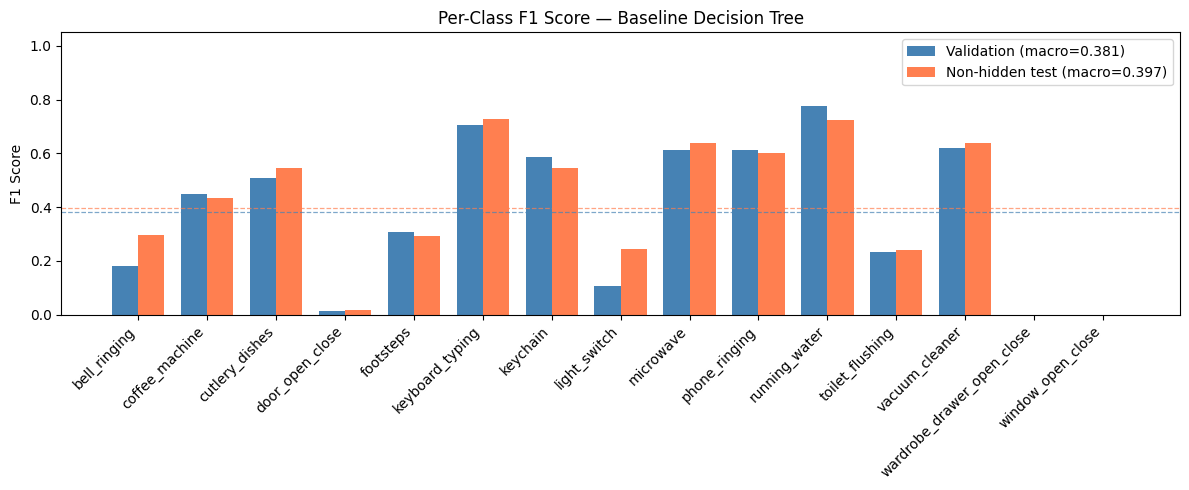

Validation macro F1:      0.3809
Non-hidden test macro F1: 0.3965


In [49]:
# Visualize per-class F1 scores for both local evaluation splits
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(CLASS_NAMES))
width = 0.38

ax.bar(x - width / 2, results_val["f1"], width, label=f"Validation (macro={macro_f1_val:.3f})",  color="steelblue")
ax.bar(x + width / 2, results_nht["f1"], width, label=f"Non-hidden test (macro={macro_f1_nht:.3f})", color="coral")

ax.axhline(macro_f1_val, color="steelblue", linestyle="--", linewidth=0.9, alpha=0.7)
ax.axhline(macro_f1_nht, color="coral",     linestyle="--", linewidth=0.9, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(results_val["annotation"], rotation=45, ha="right")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class F1 Score — Baseline Decision Tree")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Validation macro F1:      {macro_f1_val:.4f}")
print(f"Non-hidden test macro F1: {macro_f1_nht:.4f}")

<a id='8'></a>
## 8. Generating Predictions for the Hidden Test Set

Once you are satisfied with your system's local performance, generate predictions for the hidden test set and save them as a CSV file for submission.

The hidden test set has no annotations — local evaluation is not possible. Final rankings are determined by the teaching team using the macro F1 score on this set.

### Submission format

The output CSV must have exactly these columns:

| Column | Description |
|--------|-------------|
| `filename` | Audio filename, e.g. `000112.wav` |
| `annotation` | Predicted sound event class (must be one of the 15 class names) |
| `onset` | Start time of the detected event in seconds |
| `offset` | End time of the detected event in seconds |

Multiple rows can share the same `filename` (one row per detected event interval). Files with no detected events are simply omitted from the CSV.

Example:
```
filename,annotation,onset,offset
000001.wav,keyboard_typing,0.0,21.0
000001.wav,phone_ringing,9.0,18.0
000112.wav,footsteps,3.0,7.0
```

In [50]:
print(f"Generating predictions for {len(test_files)} hidden test recordings...")
pred_test_df = generate_predictions(test_files, clf)
# Begin of experiment
print(f"Original validation rows: {len(pred_test_df)}")

# Apply refinement (Tweak thresholds based on your local validation split score!)
pred_test_df_refined = refine_predictions(
    pred_test_df, 
    min_event_duration=2.0,  # drop single-second isolated blips
    min_gap_duration=2.0     # bridge 1-2 second dropouts
)

print(f"Refined rows: {len(pred_test_df_refined)}")
# End of experiment

print(f"Done. {len(pred_test_df_refined)} event intervals across "
      f"{pred_test_df_refined['filename'].nunique() if len(pred_test_df_refined) > 0 else 0} files.")

pred_test_df.head(10)

Generating predictions for 1007 hidden test recordings...
Original validation rows: 5291
Refined rows: 2018
Done. 2018 event intervals across 925 files.


,filename,annotation,onset,offset
0,000020.wav,footsteps,6.0,8.0
1,000020.wav,footsteps,18.0,20.0
2,000020.wav,footsteps,27.0,31.0
3,000020.wav,keyboard_typing,13.0,14.0
4,000020.wav,keyboard_typing,26.0,27.0
5,000021.wav,door_open_close,17.0,18.0
6,000021.wav,door_open_close,21.0,22.0
7,000021.wav,footsteps,5.0,6.0
8,000021.wav,footsteps,13.0,14.0
9,000021.wav,footsteps,15.0,16.0


In [51]:
OUTPUT_CSV = "predictions_hidden_test.csv"
pred_test_df.to_csv(OUTPUT_CSV, index=False)
print(f"Predictions saved to: {OUTPUT_CSV}")
print(f"Total rows: {len(pred_test_df)}")
print(f"Classes predicted: {sorted(pred_test_df['annotation'].unique()) if len(pred_test_df) > 0 else []}")

Predictions saved to: predictions_hidden_test.csv
Total rows: 5291
Classes predicted: ['bell_ringing', 'coffee_machine', 'cutlery_dishes', 'door_open_close', 'footsteps', 'keyboard_typing', 'keychain', 'light_switch', 'microwave', 'phone_ringing', 'running_water', 'toilet_flushing', 'vacuum_cleaner', 'wardrobe_drawer_open_close']
